# Atlas EDA — Driver Notebook

Exploratory analysis of the parsed Raman dataset (87 files, 7,999 spectra after
the 200-pixel-per-file cap). Blocks 1–8 follow PLAN.md §4.

Quick orientation:
- **Wavenumber (cm⁻¹)** is the x-axis. It's a frequency-like unit Raman folks
  use — each peak corresponds to a specific molecular vibration. Higher
  wavenumber = higher-frequency vibration.
- **Intensity** is the y-axis. Raw counts from the spectrometer (here, 16-bit).
- The "fingerprint region" (~400–1800 cm⁻¹) is where most chemical info lives.
  The C-H stretch region (~2800–3050) carries lipid/protein signal too.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
CACHE = REPO_ROOT / "data_cache"
OUT = REPO_ROOT / "outputs" / "eda"
OUT.mkdir(parents=True, exist_ok=True)

# Style
sns.set_context("notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["figure.facecolor"] = "white"

# Class color palette (consistent across all plots)
CLASS_COLORS = {
    "STEC":       "#d62728",
    "Non-STEC":   "#1f77b4",
    "Salmonella": "#2ca02c",
    "H2O":        "#7f7f7f",
}
SUBCLASS_COLORS = {
    # STEC reds
    "O103H2":   "#d62728",
    "O121H19":  "#e7665a",
    "O157H7":   "#a02124",
    # Non-STEC blues
    "83972":      "#1f77b4",
    "ATCC25922":  "#5fa6d8",
    "K-12":       "#114573",
    # Salmonella greens
    "Dublin":      "#2ca02c",
    "Heidelburg":  "#73c073",
    "Typhimurium": "#175f17",
    # H2O grey
    None: "#7f7f7f",
}

CLASS_ORDER = ["STEC", "Non-STEC", "Salmonella", "H2O"]

In [2]:
# Load the cache
from atlas.io import load_cache

spec_df, X, wn, meta = load_cache(CACHE)

print(f"spectra parquet : {spec_df.shape}")
print(f"intensities     : {X.shape}  dtype={X.dtype}")
print(f"wn axis         : {wn.shape}  range=[{wn[0]:.1f}, {wn[-1]:.1f}] cm-1")
print(f"metadata        : {meta.shape}")
print()
print("Per-class spectra:")
print(spec_df["primary_class"].value_counts())

spectra parquet : (7999, 6)
intensities     : (7999, 2048)  dtype=float32
wn axis         : (2048,)  range=[76.0, 3499.0] cm-1
metadata        : (87, 23)

Per-class spectra:
primary_class
STEC          2544
Salmonella    2544
Non-STEC      2144
H2O            767
Name: count, dtype: int64


## Block 1 — Inventory

How many files and how many pixels (= spectra) we have per class and subclass.

**What to look for:**
- Class imbalance. H₂O has way fewer files than the bacterial classes.
- Subclass imbalance within a bacterial class would be a leakage risk (a
  classifier could win by memorizing one strain).

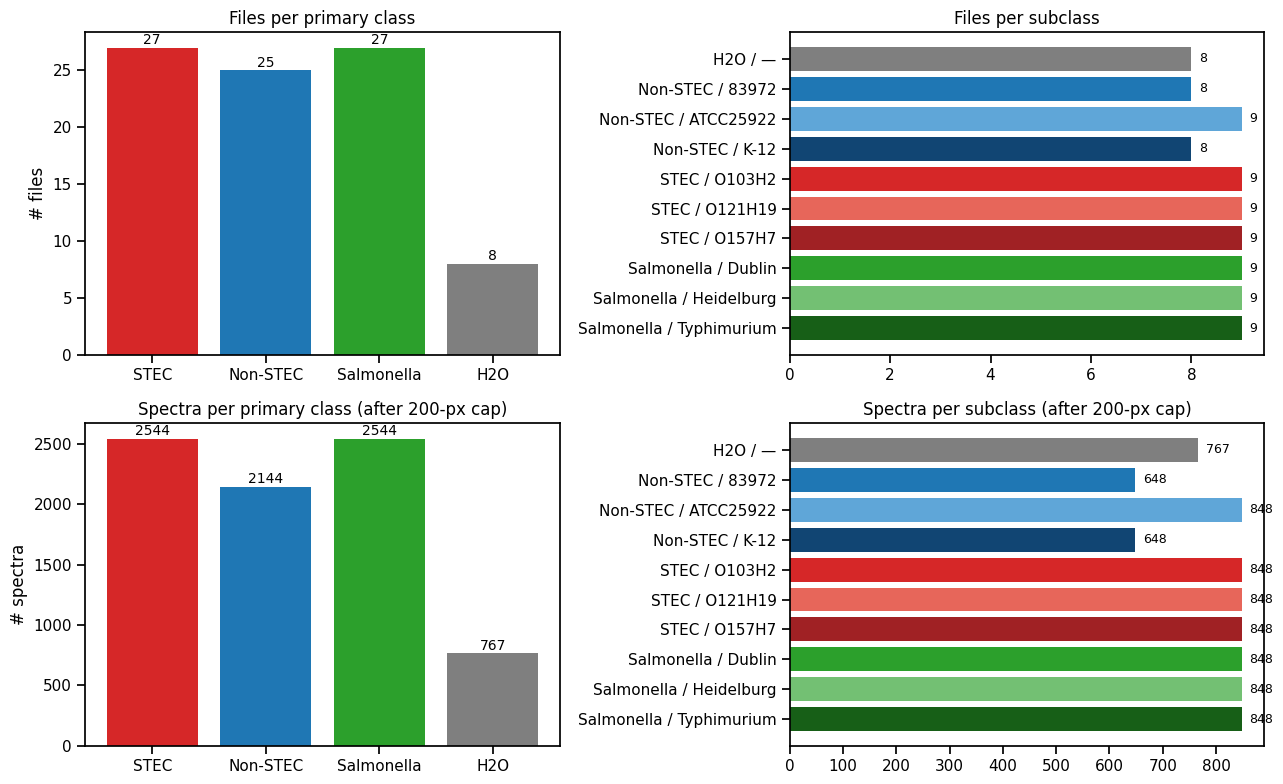

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Files per class
counts = meta["primary_class"].value_counts().reindex(CLASS_ORDER)
axes[0, 0].bar(counts.index, counts.values,
               color=[CLASS_COLORS[c] for c in counts.index])
axes[0, 0].set_title("Files per primary class")
axes[0, 0].set_ylabel("# files")
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 0.3, str(v), ha="center", fontsize=10)

# Files per subclass
sub_counts = (
    meta.assign(label=lambda d: d["primary_class"] + " / " + d["subclass"].fillna("—"))
    ["label"].value_counts().sort_index()
)
colors = [SUBCLASS_COLORS.get(lbl.split(" / ")[1] if " / " in lbl and lbl.split(" / ")[1] != "—" else None, "#7f7f7f")
          for lbl in sub_counts.index]
axes[0, 1].barh(sub_counts.index, sub_counts.values, color=colors)
axes[0, 1].set_title("Files per subclass")
axes[0, 1].invert_yaxis()
for i, v in enumerate(sub_counts.values):
    axes[0, 1].text(v + 0.15, i, str(v), va="center", fontsize=9)

# Pixels per class (post-cap)
px_class = spec_df["primary_class"].value_counts().reindex(CLASS_ORDER)
axes[1, 0].bar(px_class.index, px_class.values,
               color=[CLASS_COLORS[c] for c in px_class.index])
axes[1, 0].set_title("Spectra per primary class (after 200-px cap)")
axes[1, 0].set_ylabel("# spectra")
for i, v in enumerate(px_class.values):
    axes[1, 0].text(i, v + 30, str(v), ha="center", fontsize=10)

# Pixels per subclass
spec_lbl = spec_df.assign(
    label=lambda d: d["primary_class"] + " / " + d["subclass"].fillna("—")
)
px_sub = spec_lbl["label"].value_counts().sort_index()
sub_colors = [SUBCLASS_COLORS.get(lbl.split(" / ")[1] if " / " in lbl and lbl.split(" / ")[1] != "—" else None, "#7f7f7f")
              for lbl in px_sub.index]
axes[1, 1].barh(px_sub.index, px_sub.values, color=sub_colors)
axes[1, 1].set_title("Spectra per subclass (after 200-px cap)")
axes[1, 1].invert_yaxis()
for i, v in enumerate(px_sub.values):
    axes[1, 1].text(v + 15, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "01_inventory.png", bbox_inches="tight")
plt.show()

## Block 2 — Class mean spectra (raw)

For each primary class, compute mean(intensity) and std(intensity) per
wavenumber bin across all spectra in that class. Shaded band = ±1σ.

**What to look for:**
- Peak *locations* differing between classes → discriminative information.
- Wide vs narrow ±1σ bands → within-class consistency.
- Big baseline humps (smooth curves under the peaks) → exactly what
  preprocessing (arPLS baseline) is going to remove later.

Note: this is **raw** intensity, no preprocessing. The shapes look noisy
because of fluorescence baselines that vary file-to-file. We'll redo this
plot once `atlas/preprocess.py` is built.

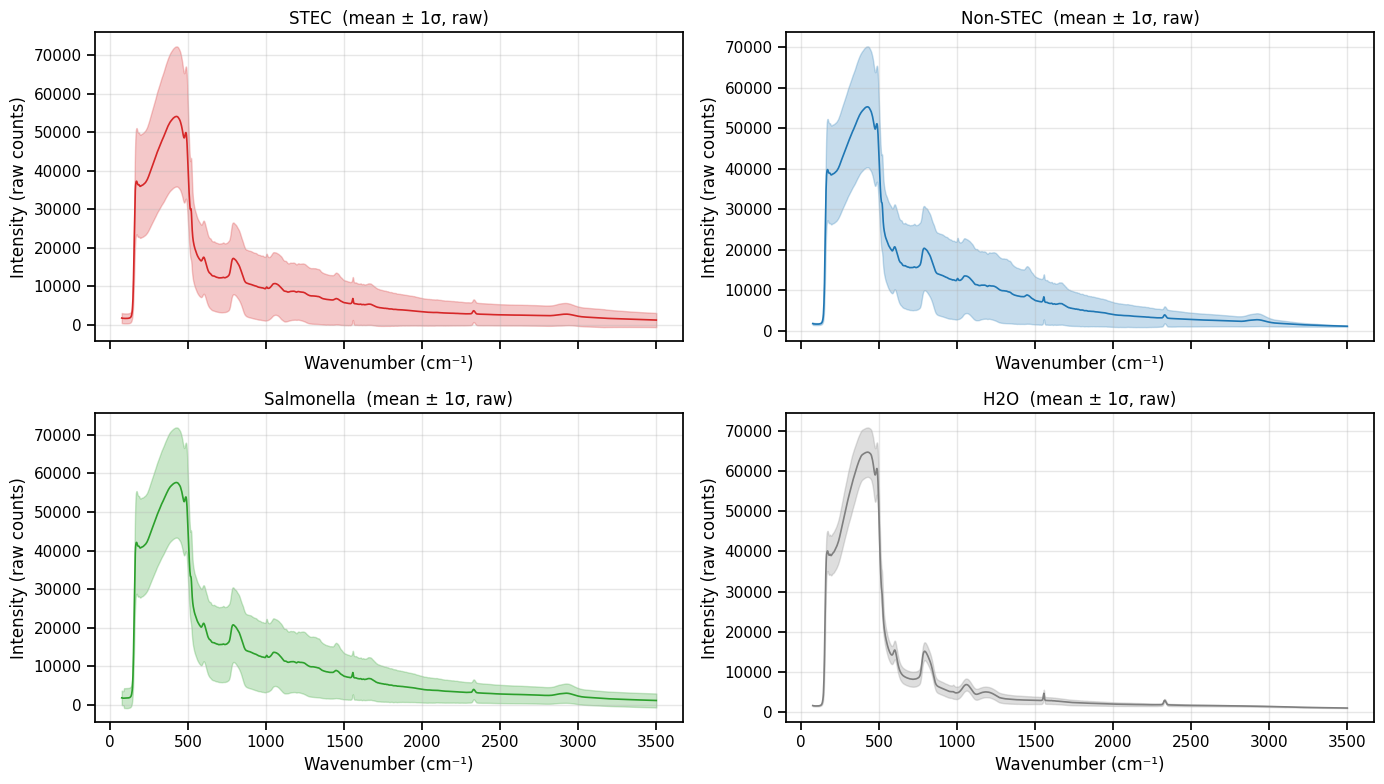

In [4]:
def mean_std_per_class(X, labels):
    out = {}
    for c in CLASS_ORDER:
        m = labels == c
        out[c] = (X[m].mean(0), X[m].std(0))
    return out

stats = mean_std_per_class(X, spec_df["primary_class"].values)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, c in zip(axes.flat, CLASS_ORDER):
    mu, sd = stats[c]
    ax.fill_between(wn, mu - sd, mu + sd, alpha=0.25, color=CLASS_COLORS[c])
    ax.plot(wn, mu, color=CLASS_COLORS[c], lw=1.2)
    ax.set_title(f"{c}  (mean ± 1σ, raw)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Intensity (raw counts)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "02_class_means_raw.png", bbox_inches="tight")
plt.show()

### A simple in-notebook preview of preprocessing

Full preprocessing (arPLS baseline → Savitzky-Golay → crop → SNV) lives in
`atlas/preprocess.py`, which is the next module to build. For visual sanity
right now, here's a lightweight crop + SNV — enough to see whether peak
shapes line up across classes once the fluorescence baseline is muted by
per-spectrum normalization.

cropped to 987 bins from 2048
SNV: mean=-3.75e-04, std=1.000  (expected ~0, ~1)


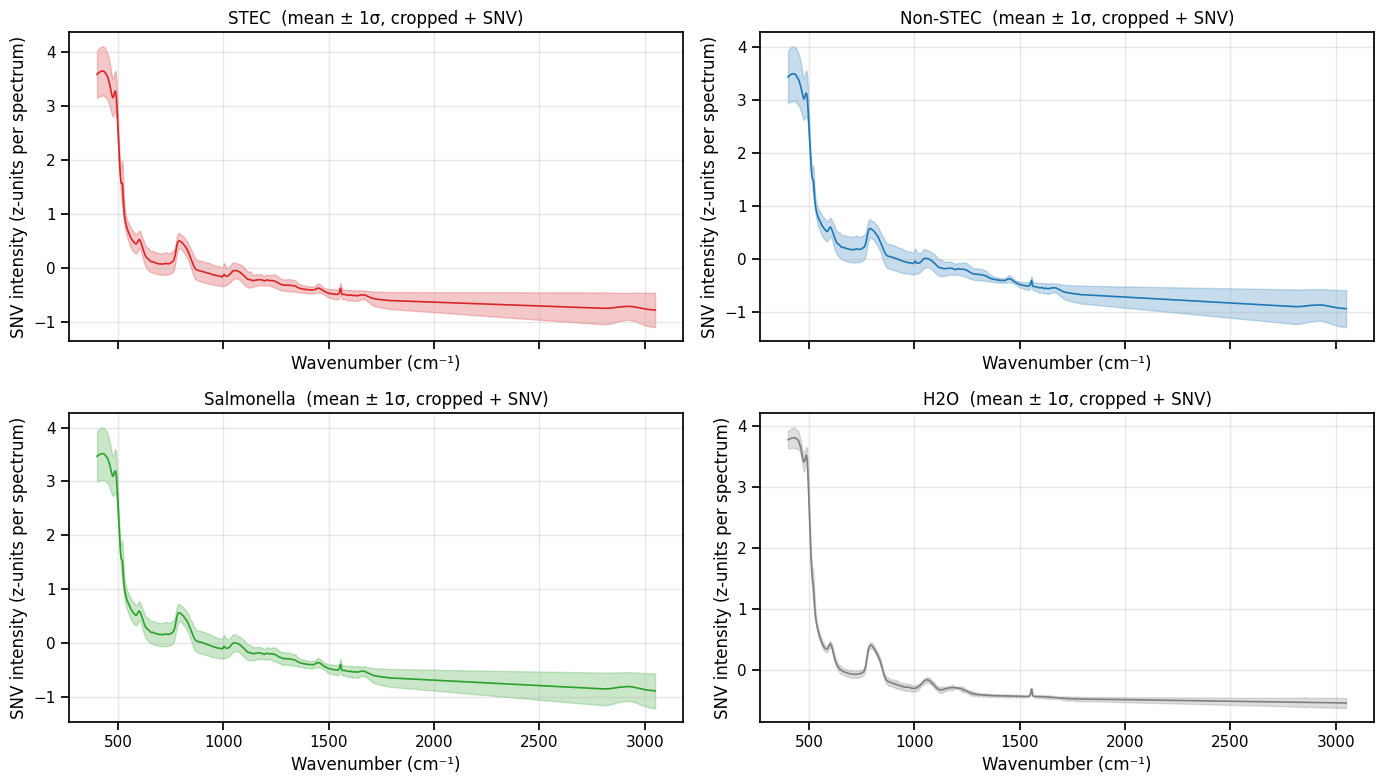

In [5]:
# Crop to fingerprint + C-H stretch, then SNV-normalize each spectrum.
# This is NOT the full pipeline — just enough to see comparable peak shapes.
def crop_two_regions(X, wn, r1=(400, 1800), r2=(2800, 3050)):
    m1 = (wn >= r1[0]) & (wn <= r1[1])
    m2 = (wn >= r2[0]) & (wn <= r2[1])
    keep = m1 | m2
    return X[:, keep], wn[keep], keep

def snv(X):
    mu = X.mean(1, keepdims=True)
    sd = X.std(1, keepdims=True) + 1e-8
    return (X - mu) / sd

Xc, wnc, keep_mask = crop_two_regions(X, wn)
Xn = snv(Xc)
print(f"cropped to {Xc.shape[1]} bins from {X.shape[1]}")
print(f"SNV: mean={Xn.mean():.2e}, std={Xn.std():.3f}  (expected ~0, ~1)")

stats_n = mean_std_per_class(Xn, spec_df["primary_class"].values)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, c in zip(axes.flat, CLASS_ORDER):
    mu, sd = stats_n[c]
    ax.fill_between(wnc, mu - sd, mu + sd, alpha=0.25, color=CLASS_COLORS[c])
    ax.plot(wnc, mu, color=CLASS_COLORS[c], lw=1.2)
    ax.set_title(f"{c}  (mean ± 1σ, cropped + SNV)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("SNV intensity (z-units per spectrum)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "02b_class_means_snv.png", bbox_inches="tight")
plt.show()

## Block 3 — PCA scatter

PCA finds the directions in 2048-dim space that capture the most variance
across all spectra. We fit on the cropped+SNV data so we're looking at
chemical signal, not fluorescence baselines.

**What "good" looks like:**
- Classes form visually distinct clusters in PC1–PC2 → easy classification.
- Classes overlap heavily → most discriminative info is in higher PCs;
  classical linear models may struggle and we'll lean on nonlinear ones.

**Why we look at both class and subclass coloring:**
- If subclasses are visible as sub-blobs within a class, that's good
  (model can predict the parent class robustly).
- If subclasses are *more* separated from each other than they are from
  the other parent's subclasses, that's a leakage risk — the model
  could learn strain identity rather than parent class.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale (StandardScaler per bin) then PCA
scaler = StandardScaler()
Xs = scaler.fit_transform(Xn)

pca = PCA(n_components=20, random_state=0).fit(Xs)
Z = pca.transform(Xs)
print(f"PCA shape: {Z.shape}")
print(f"variance explained (top 10): {np.round(pca.explained_variance_ratio_[:10], 3)}")
print(f"cumulative variance (top 10): {np.round(pca.explained_variance_ratio_[:10].cumsum(), 3)}")

PCA shape: (7999, 20)
variance explained (top 10): [0.801 0.136 0.016 0.014 0.009 0.006 0.004 0.004 0.002 0.002]
cumulative variance (top 10): [0.801 0.936 0.953 0.966 0.975 0.982 0.986 0.989 0.992 0.993]


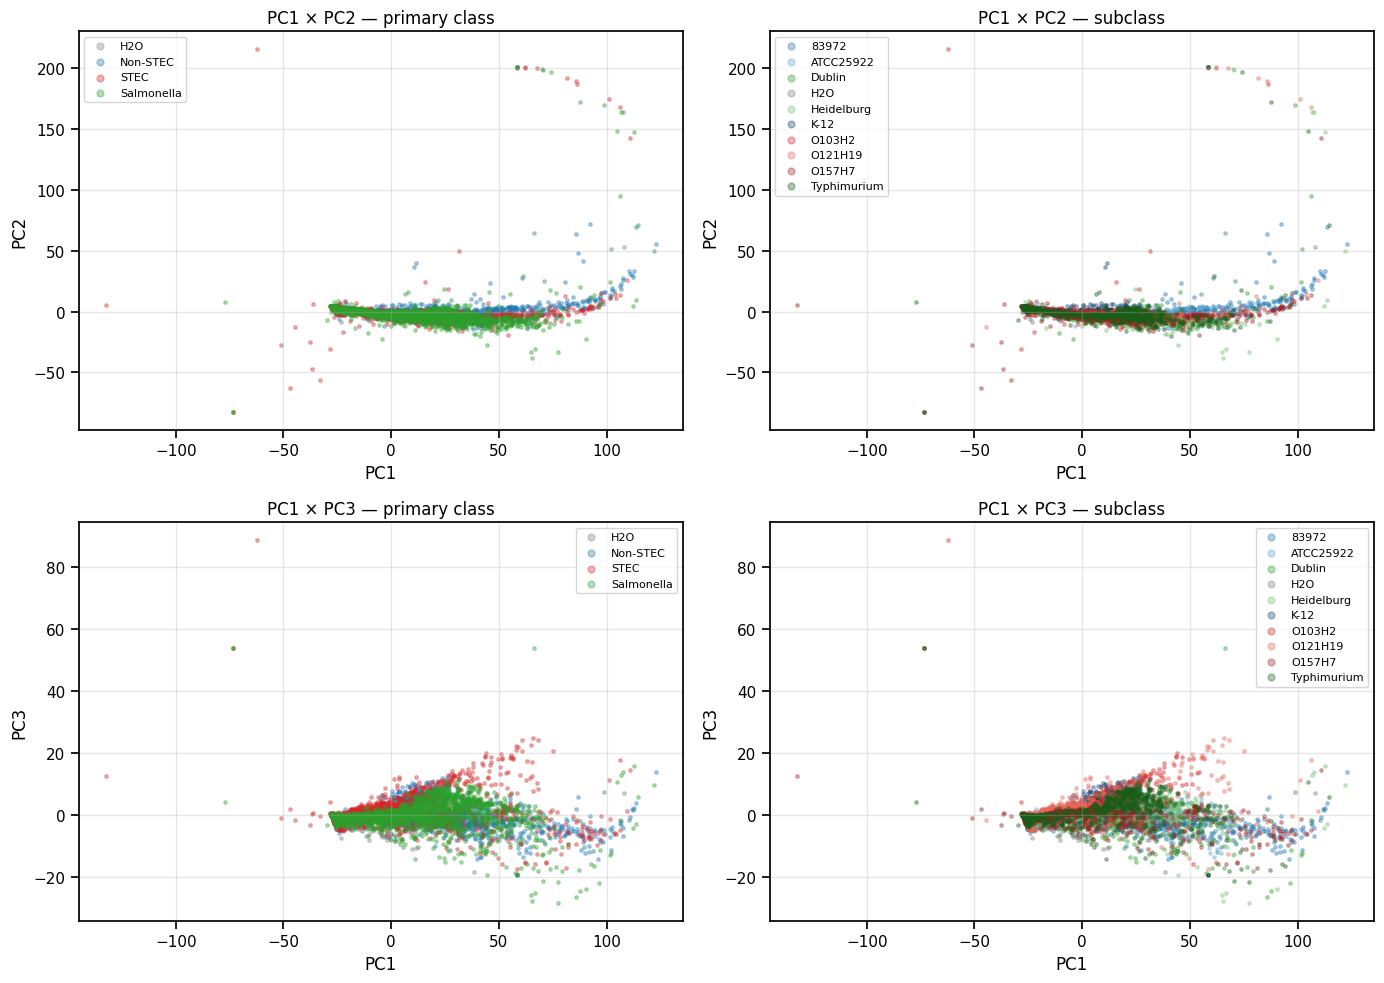

In [7]:
labels_class = spec_df["primary_class"].values
labels_sub = spec_df["subclass"].fillna("H2O").values

def scatter(ax, x, y, labels, palette, title, alpha=0.35, s=6):
    for lbl in sorted(set(labels), key=lambda v: (v is None, str(v))):
        m = labels == lbl
        ax.scatter(x[m], y[m], s=s, alpha=alpha,
                   color=palette.get(lbl, "#888"), label=str(lbl))
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=8, loc="best", markerscale=2)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 1: PC1–PC2
scatter(axes[0, 0], Z[:, 0], Z[:, 1], labels_class, CLASS_COLORS,
        "PC1 × PC2 — primary class")
scatter(axes[0, 1], Z[:, 0], Z[:, 1], labels_sub,
        {**SUBCLASS_COLORS, "H2O": "#7f7f7f"},
        "PC1 × PC2 — subclass")

# Row 2: PC1–PC3
for ax in axes[1]:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC3")
scatter(axes[1, 0], Z[:, 0], Z[:, 2], labels_class, CLASS_COLORS,
        "PC1 × PC3 — primary class")
scatter(axes[1, 1], Z[:, 0], Z[:, 2], labels_sub,
        {**SUBCLASS_COLORS, "H2O": "#7f7f7f"},
        "PC1 × PC3 — subclass")
axes[1, 0].set_ylabel("PC3"); axes[1, 1].set_ylabel("PC3")

plt.tight_layout()
plt.savefig(OUT / "03_pca_scatter.png", bbox_inches="tight")
plt.show()

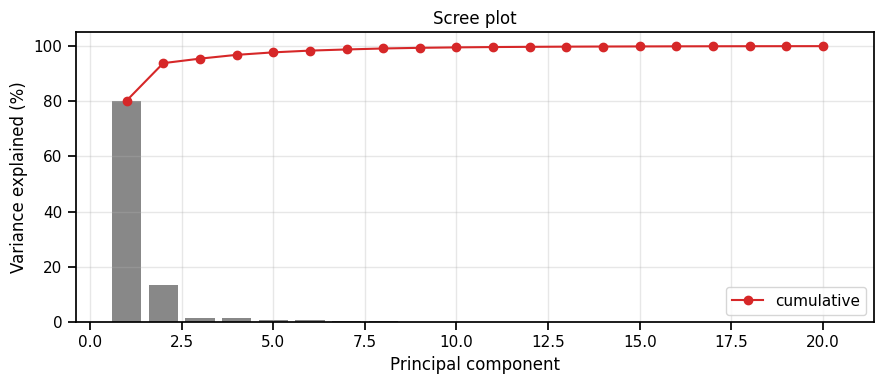

In [8]:
# Scree plot — how much variance each PC carries
fig, ax = plt.subplots(figsize=(9, 4))
n = 20
ax.bar(range(1, n + 1), pca.explained_variance_ratio_[:n] * 100, color="#888")
ax.plot(range(1, n + 1), pca.explained_variance_ratio_[:n].cumsum() * 100,
        marker="o", color="#d62728", label="cumulative")
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
ax.set_title("Scree plot")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "03b_scree.png", bbox_inches="tight")
plt.show()

## Block 4 — UMAP on first 50 PCs

UMAP is a nonlinear projection that tries to preserve local neighbor
structure. Where PCA is forced to use straight (linear) axes, UMAP can
"bend" the space.

**Reading a UMAP plot:**
- Distance within a cluster = roughly meaningful.
- Distance *between* clusters = NOT meaningful (UMAP can compress big
  gaps). Cluster shapes are partly artifacts of the algorithm.
- Look for: do classes form distinct islands? Do subclasses form
  sub-islands within parent classes?

UMAP shape: (7999, 2)


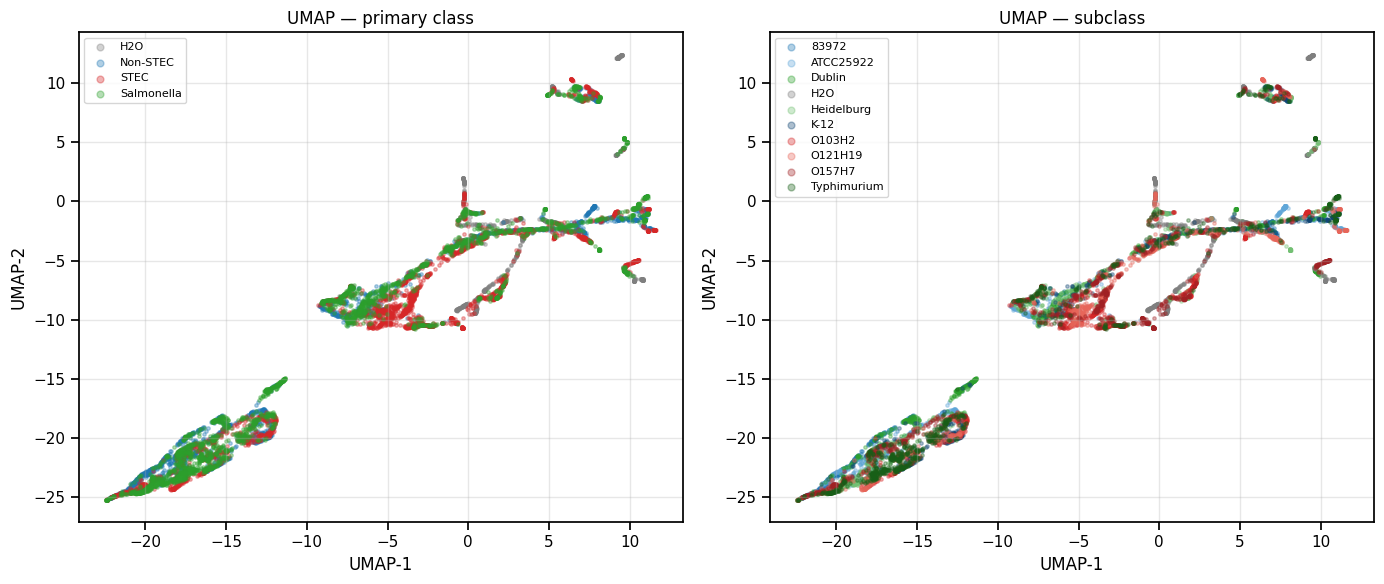

In [9]:
import umap

reducer = umap.UMAP(
    n_components=2, n_neighbors=30, min_dist=0.1,
    metric="euclidean", random_state=0
)
U = reducer.fit_transform(Z[:, :50])
print(f"UMAP shape: {U.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter(axes[0], U[:, 0], U[:, 1], labels_class, CLASS_COLORS,
        "UMAP — primary class")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
scatter(axes[1], U[:, 0], U[:, 1], labels_sub,
        {**SUBCLASS_COLORS, "H2O": "#7f7f7f"},
        "UMAP — subclass")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
plt.tight_layout()
plt.savefig(OUT / "04_umap.png", bbox_inches="tight")
plt.show()

## Block 5 — Top peaks per class

For each class, find the 10 strongest peaks in the **class-mean SNV
spectrum** and label them by wavenumber. Raman peaks have known
biological identities; reference annotations included where known.

**Why this matters:** if STEC and Non-STEC mean spectra share most of
their peaks (both are E. coli, after all), the discriminative signal will
be in peak *intensities* rather than peak *locations*, and the model has
to learn ratios across bins.

**Common Raman bands in bacteria:**
| ~cm⁻¹ | Vibration | Origin |
|---|---|---|
| 720–780 | ring breathing | nucleic acid bases (A, G, T) |
| 1004 | symmetric ring | phenylalanine (protein) |
| 1080 | C–C stretch | phospholipid backbone |
| 1250 | amide III | protein backbone |
| 1450 | CH₂ deformation | lipids (and protein side chains) |
| 1580 | C=C, ring | nucleic acid bases |
| 1660 | amide I | protein α-helix vs β-sheet |
| 2850 | sym CH₂ stretch | lipid acyl chains |
| 2930 | asym CH₂ stretch | lipid + protein |

In [10]:
from scipy.signal import find_peaks

def top_peaks(spec_1d, wn, n=10, prominence=0.05, distance=10):
    idx, props = find_peaks(spec_1d, prominence=prominence, distance=distance)
    if len(idx) == 0:
        return []
    order = np.argsort(props["prominences"])[::-1][:n]
    return [(float(wn[idx[i]]), float(spec_1d[idx[i]]), float(props["prominences"][i])) for i in order]

rows = []
for c in CLASS_ORDER:
    mu, _ = stats_n[c]
    for rank, (wnv, intensity, prom) in enumerate(top_peaks(mu, wnc, n=10), 1):
        rows.append({"class": c, "rank": rank,
                     "wn_cm-1": round(wnv, 1),
                     "intensity_z": round(intensity, 3),
                     "prominence": round(prom, 3)})
peaks_df = pd.DataFrame(rows)
print("Top peaks by class (from cropped+SNV mean spectrum):")
display = peaks_df.pivot(index="rank", columns="class", values="wn_cm-1")[CLASS_ORDER]
print(display.to_string())
peaks_df.to_csv(OUT / "05_peak_table.csv", index=False)

Top peaks by class (from cropped+SNV mean spectrum):
class    STEC  Non-STEC  Salmonella     H2O
rank                                       
1       790.0     790.0       790.0   793.4
2       487.4     487.4      1050.9  1059.3
3      1055.9    1555.9      1555.9  1555.9
4      1555.9    1050.9       487.4   487.4
5       601.1     601.1       599.4   601.1
6       427.2     427.2         NaN     NaN


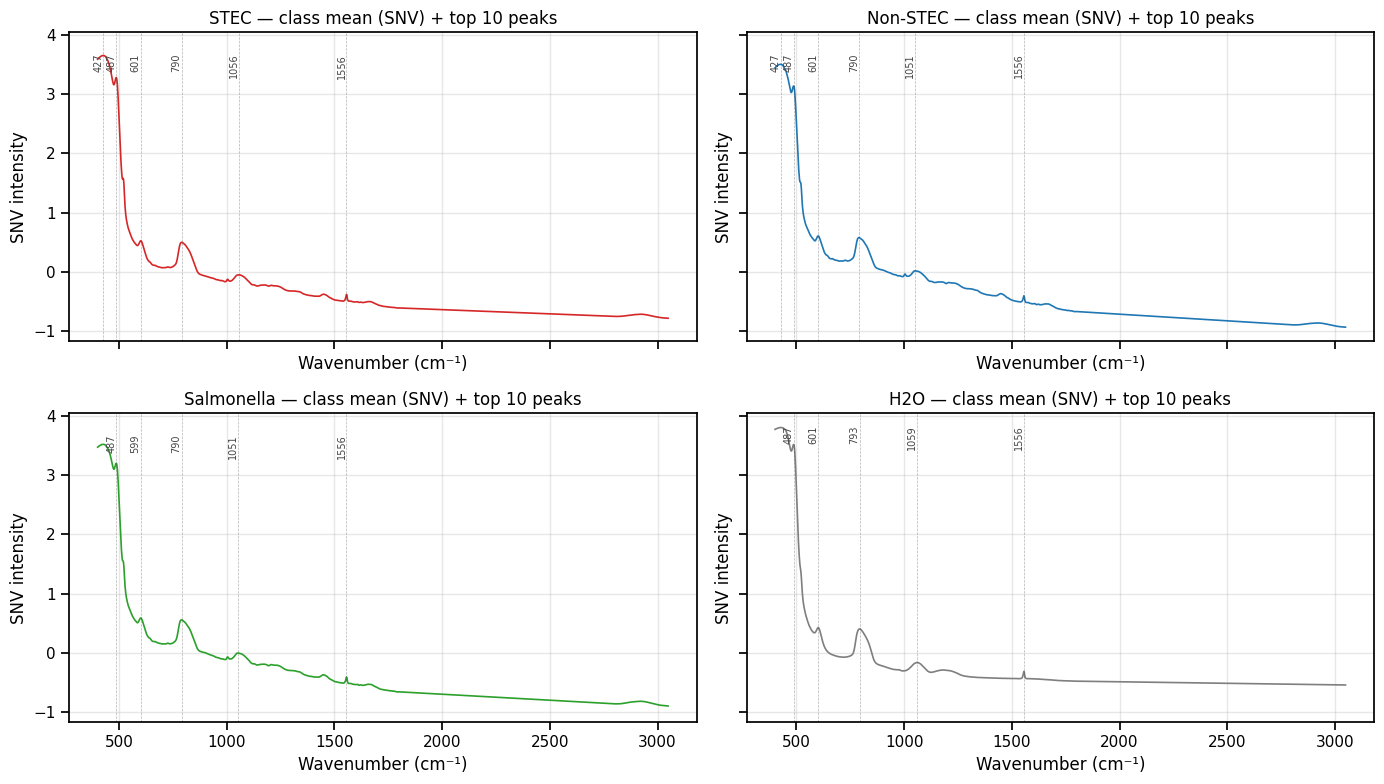

In [11]:
# Visual: overlay class means with top-peak markers
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, c in zip(axes.flat, CLASS_ORDER):
    mu, _ = stats_n[c]
    ax.plot(wnc, mu, color=CLASS_COLORS[c], lw=1.2)
    for wnv, intensity, _ in top_peaks(mu, wnc, n=10):
        ax.axvline(wnv, color="#444", lw=0.5, ls="--", alpha=0.4)
        ax.text(wnv, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else intensity + 0.1,
                f"{wnv:.0f}", rotation=90, fontsize=7, color="#444",
                ha="right", va="top")
    ax.set_title(f"{c} — class mean (SNV) + top 10 peaks")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("SNV intensity")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "05_peaks_overlay.png", bbox_inches="tight")
plt.show()

## Block 6 — Which wavenumbers separate the classes?

For each of the ~1100 cropped bins we run one-way ANOVA across the 4
primary classes. Bins where the class means differ much more than within-class
variance get a very small p-value, i.e. a *large* `-log10(p)`.

We also compute mutual information (a nonlinear, non-Gaussian-assuming
alternative). The two curves should roughly agree on which regions matter.

**What to look for:**
- Peaks of discriminative power *aligned* with biological peak locations
  → the chemical signal is what's driving separation. Good.
- Discriminative peaks at "weird" locations (between known biological bands)
  → suspicious, might be instrument artifacts that correlate with class
  due to acquisition batches. Worth flagging.

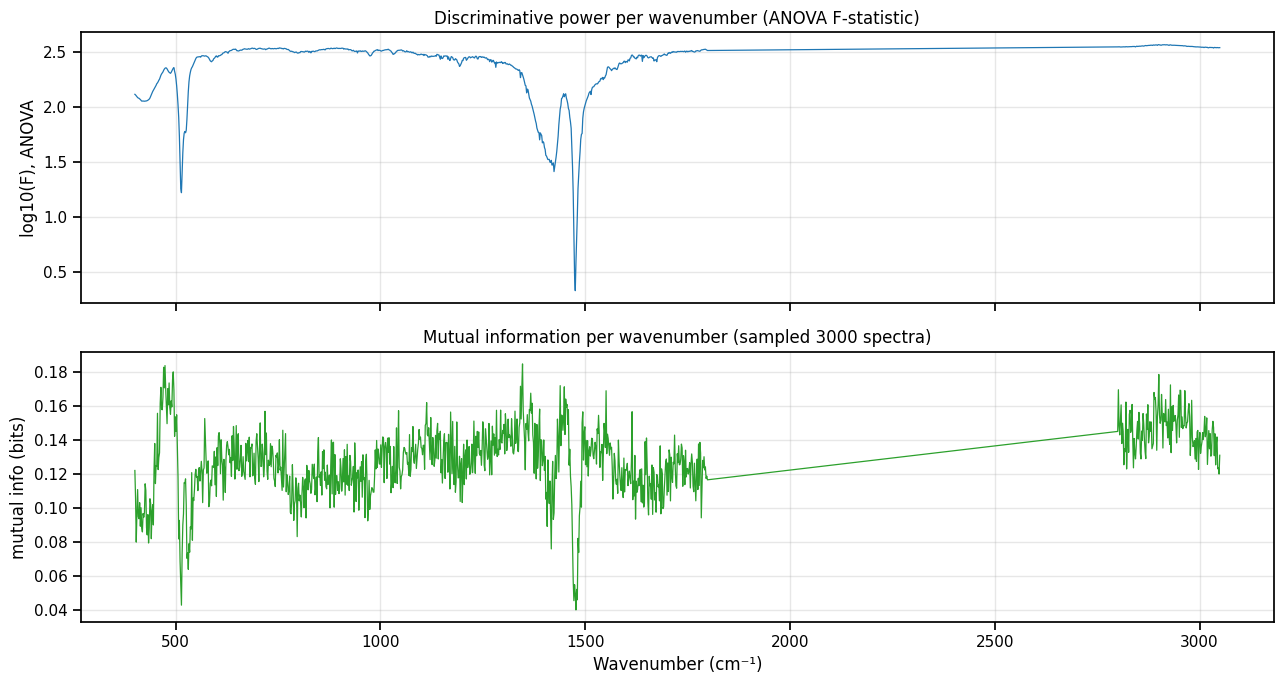

Top 30 bins by ANOVA F:
        wn_cm-1           F  log10(F)  MI (bits)
0   2900.399902  370.799988      2.57      0.179
1   2915.399902  369.899994      2.57      0.151
2   2898.699951  369.799988      2.57      0.161
3   2918.699951  369.700012      2.57      0.149
4   2910.399902  369.299988      2.57      0.135
5   2908.699951  369.299988      2.57      0.155
6   2920.399902  369.200012      2.57      0.151
7   2913.699951  369.100006      2.57      0.155
8   2928.800049  369.000000      2.57      0.173
9   2912.100098  369.000000      2.57      0.156
10  2922.100098  368.899994      2.57      0.141
11  2895.300049  368.799988      2.57      0.134
12  2892.000000  368.600006      2.57      0.165
13  2927.100098  368.500000      2.57      0.137
14  2902.000000  368.500000      2.57      0.155
15  2903.699951  368.399994      2.57      0.150
16  2917.100098  368.399994      2.57      0.164
17  2887.000000  368.200012      2.57      0.138
18  2930.500000  367.799988      2.57      0.

In [12]:
from sklearn.feature_selection import f_classif, mutual_info_classif

# Encode class labels
class_to_int = {c: i for i, c in enumerate(CLASS_ORDER)}
y = np.array([class_to_int[c] for c in spec_df["primary_class"]])

F, p = f_classif(Xn, y)
# We plot log10(F) instead of -log10(p) — for our top bins p underflows
# to 0 (numerical floor) which would make -log10(p) saturate at inf and
# break the line. F doesn't saturate; the ranking is identical.
logF = np.log10(np.maximum(F, 1e-3))

# Mutual info — slower; sample for speed
rng_idx = np.random.default_rng(0).choice(len(Xn), size=min(3000, len(Xn)), replace=False)
mi = mutual_info_classif(Xn[rng_idx], y[rng_idx], random_state=0)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(wnc, logF, color="#1f77b4", lw=0.9)
axes[0].set_ylabel("log10(F), ANOVA")
axes[0].set_title("Discriminative power per wavenumber (ANOVA F-statistic)")
axes[0].grid(alpha=0.3)

axes[1].plot(wnc, mi, color="#2ca02c", lw=0.9)
axes[1].set_ylabel("mutual info (bits)")
axes[1].set_xlabel("Wavenumber (cm⁻¹)")
axes[1].set_title("Mutual information per wavenumber (sampled 3000 spectra)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "06_anova_mi.png", bbox_inches="tight")
plt.show()

# Top discriminative bins
top_n = 30
top_idx = np.argsort(F)[::-1][:top_n]
print(f"Top {top_n} bins by ANOVA F:")
top_tbl = pd.DataFrame({
    "wn_cm-1": np.round(wnc[top_idx], 1),
    "F": np.round(F[top_idx], 1),
    "log10(F)": np.round(logF[top_idx], 2),
    "MI (bits)": np.round(mi[top_idx], 3),
}).sort_values("F", ascending=False).reset_index(drop=True)
print(top_tbl.head(30).to_string())
top_tbl.to_csv(OUT / "06_top_discriminative_bins.csv", index=False)

## Block 7 — Inter-file similarity heatmap

This is the single most predictive plot for "how hard is this dataset
going to be."

For every pair of files we compute the cosine similarity between their
mean spectra (post crop+SNV). We sort files by `[primary_class, subclass]`
so the heatmap should show **bright block-diagonal clusters**:
- Bright diagonal block per subclass = files within a strain look similar.
- Brighter block per parent class = parent classes are internally similar.
- If two files from *different* classes are brighter to each other than
  to their own class — that's a leakage red flag.

The goal here is to see structure that mirrors the labels, not random
file-to-file resemblance.

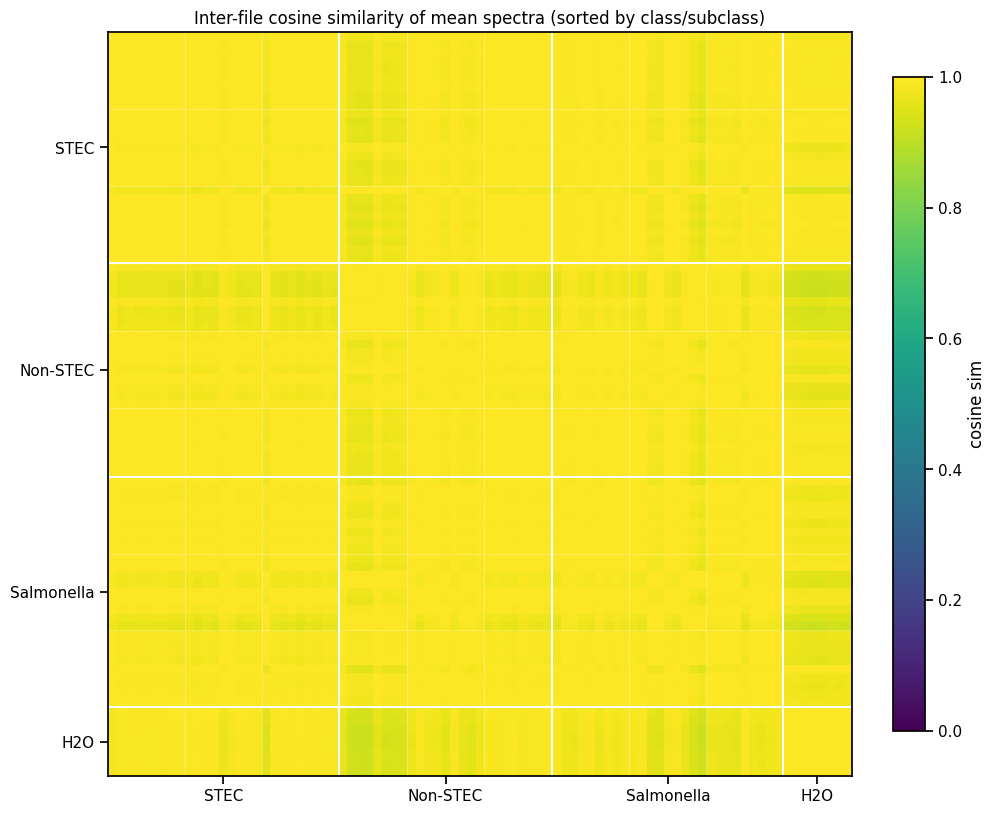

Per-class mean intra-class file-to-file cosine similarity:
  STEC          n_pairs=351  mean=0.997  min=0.970
  Non-STEC      n_pairs=300  mean=0.991  min=0.961
  Salmonella    n_pairs=351  mean=0.994  min=0.955
  H2O           n_pairs=28  mean=0.999  min=0.997


In [13]:
# Per-file mean spectrum
file_means = []
file_ids = []
file_labels = []
for fid, g in spec_df.groupby("file_id", sort=False):
    file_ids.append(fid)
    idx = g.index.to_numpy()
    file_means.append(Xn[idx].mean(0))
    # Use the file's primary_class + subclass
    pc = g["primary_class"].iloc[0]
    sc = g["subclass"].iloc[0]
    file_labels.append((pc, sc if isinstance(sc, str) else "—"))

file_means = np.asarray(file_means)

# Sort by (primary_class, subclass)
order = sorted(range(len(file_ids)),
               key=lambda i: (CLASS_ORDER.index(file_labels[i][0]),
                              file_labels[i][1], file_ids[i]))
file_means_s = file_means[order]
labels_s = [file_labels[i] for i in order]
ids_s = [file_ids[i] for i in order]

# Cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
S = cosine_similarity(file_means_s)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(S, cmap="viridis", vmin=0, vmax=1)
ax.set_title("Inter-file cosine similarity of mean spectra (sorted by class/subclass)")

# Class boundaries
class_boundaries = []
prev = None
for i, (pc, _) in enumerate(labels_s):
    if pc != prev:
        class_boundaries.append((i, pc))
        prev = pc
for b, pc in class_boundaries[1:]:
    ax.axhline(b - 0.5, color="white", lw=1.5)
    ax.axvline(b - 0.5, color="white", lw=1.5)

# Subclass boundaries (thinner)
prev = None
for i, (pc, sc) in enumerate(labels_s):
    key = (pc, sc)
    if key != prev:
        ax.axhline(i - 0.5, color="white", lw=0.4, alpha=0.5)
        ax.axvline(i - 0.5, color="white", lw=0.4, alpha=0.5)
        prev = key

# Labels at class boundaries
tick_pos = []
tick_lbl = []
for b, pc in class_boundaries:
    # find midpoint of this class block
    end = next((bb for bb, _ in class_boundaries[class_boundaries.index((b, pc)) + 1:]),
               len(labels_s))
    tick_pos.append((b + end) / 2 - 0.5)
    tick_lbl.append(pc)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbl)
plt.colorbar(im, ax=ax, fraction=0.04, label="cosine sim")
plt.tight_layout()
plt.savefig(OUT / "07_interfile_heatmap.png", bbox_inches="tight")
plt.show()

# Summary statistics
print("Per-class mean intra-class file-to-file cosine similarity:")
for c in CLASS_ORDER:
    idxs = [i for i, (pc, _) in enumerate(labels_s) if pc == c]
    if len(idxs) < 2:
        continue
    block = S[np.ix_(idxs, idxs)]
    iu = np.triu_indices_from(block, k=1)
    print(f"  {c:12s}  n_pairs={len(iu[0])}  mean={block[iu].mean():.3f}  min={block[iu].min():.3f}")

## Block 8 — Subclass overlay, silhouette, LDA ratio

The assessment specifically asks us to show subclass-awareness. This block
quantifies it.

1. **Per-subclass mean overlay** — visualize all subclasses on one plot
   per parent class. Are sister-strains visually distinct?
2. **Silhouette score** in PCA space — for each *spectrum*, is it closer
   to its own subclass centroid than to the nearest other subclass? Score
   in [-1, 1]; positive = well-clustered, negative = misplaced. We report
   silhouette over **subclass labels** (so H₂O is one cluster).
3. **LDA between-subclass / total variance ratio** — proportion of total
   variance that lies *between* subclasses vs *within* them. Higher = the
   subclass label is easier to predict from the spectrum.

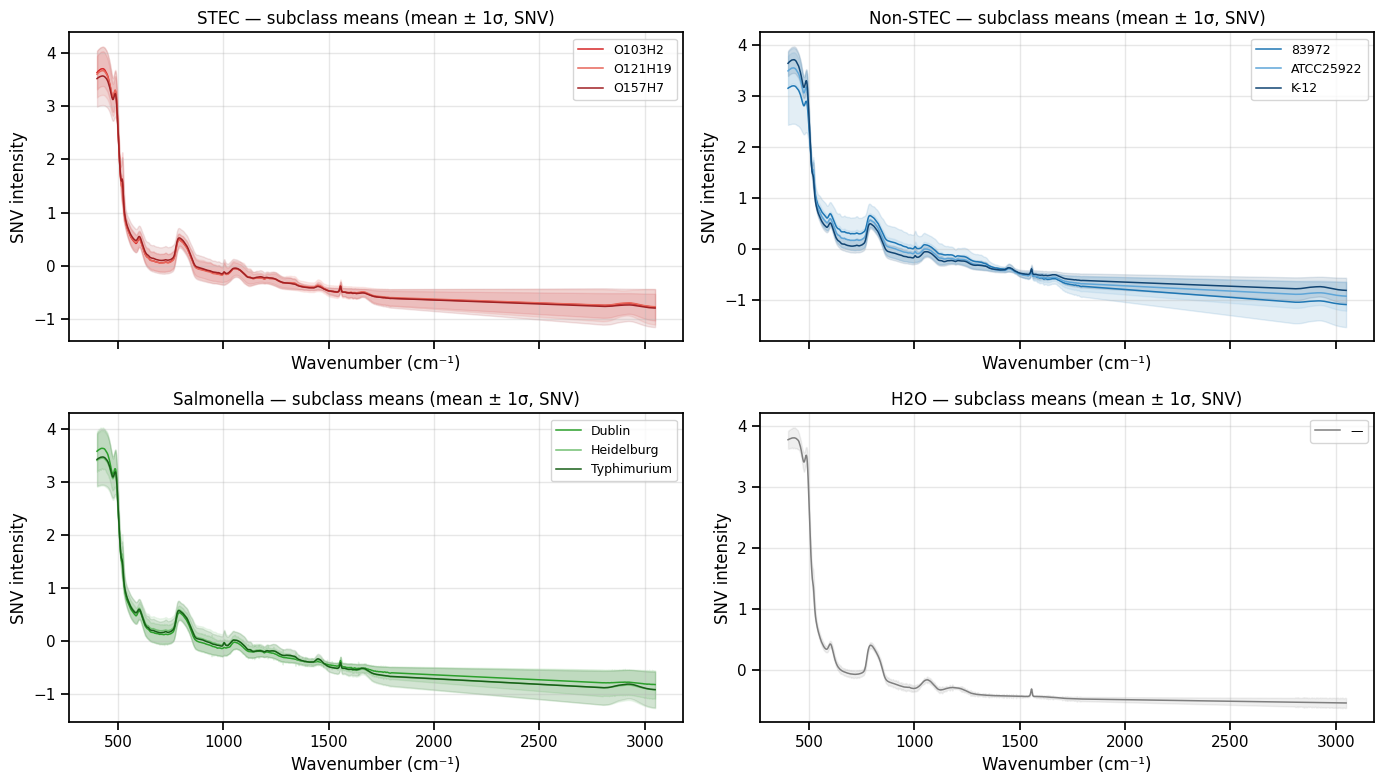

In [14]:
# 8.1 Per-subclass mean overlay (one panel per parent class)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, parent in zip(axes.flat, CLASS_ORDER):
    sub_in_class = sorted({sc for pc, sc in zip(
        spec_df["primary_class"], spec_df["subclass"].fillna("—")
    ) if pc == parent})
    for sc in sub_in_class:
        m = (spec_df["primary_class"].values == parent)
        if sc != "—":
            m = m & (spec_df["subclass"].fillna("—").values == sc)
        mu = Xn[m].mean(0)
        sd = Xn[m].std(0)
        color = SUBCLASS_COLORS.get(sc if sc != "—" else None, "#888")
        ax.plot(wnc, mu, color=color, lw=1.1, label=sc)
        ax.fill_between(wnc, mu - sd, mu + sd, color=color, alpha=0.12)
    ax.set_title(f"{parent} — subclass means (mean ± 1σ, SNV)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("SNV intensity")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "08_subclass_overlay.png", bbox_inches="tight")
plt.show()

Overall subclass silhouette (PCA-50 space, n=4000): -0.254

Per-subclass mean silhouette:
             mean_sil    n
sub                       
H2O          0.711312  378
ATCC25922   -0.187434  433
Dublin      -0.289344  410
K-12        -0.311297  311
O103H2      -0.343986  436
Typhimurium -0.382145  415
83972       -0.384716  322
Heidelburg  -0.391610  448
O121H19     -0.437293  426
O157H7      -0.462702  421


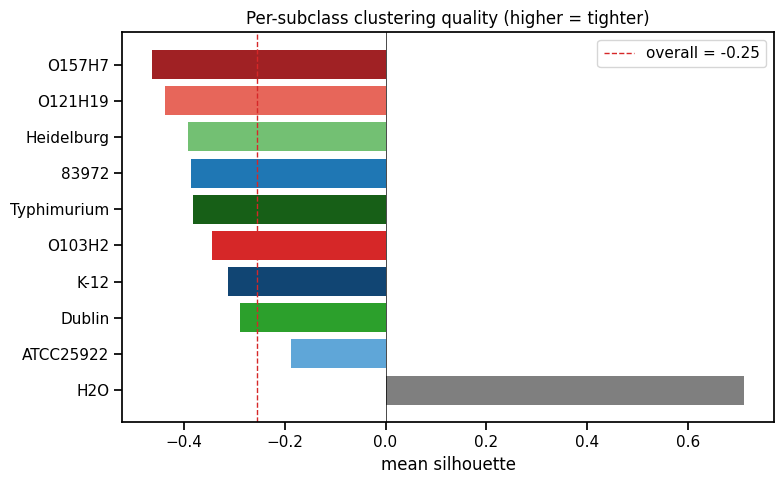

In [15]:
# 8.2 Silhouette in PCA-50 space, subclass labels (H2O treated as its own subclass)
from sklearn.metrics import silhouette_score, silhouette_samples

# subclass labels (H2O -> 'H2O')
sub_lbl = spec_df["subclass"].fillna("H2O").values

# Subsample for silhouette tractability
n_sample = min(4000, len(Xn))
rng = np.random.default_rng(0)
idx_s = rng.choice(len(Xn), size=n_sample, replace=False)

Z50 = Z[:, :50]  # already computed in block 3
score_overall = silhouette_score(Z50[idx_s], sub_lbl[idx_s], metric="euclidean")
print(f"Overall subclass silhouette (PCA-50 space, n={n_sample}): {score_overall:.3f}")

# Per-subclass mean silhouette
sample_vals = silhouette_samples(Z50[idx_s], sub_lbl[idx_s])
per_sub = pd.DataFrame({"sub": sub_lbl[idx_s], "sil": sample_vals}).groupby("sub").agg(
    mean_sil=("sil", "mean"), n=("sil", "size")
).sort_values("mean_sil", ascending=False)
print()
print("Per-subclass mean silhouette:")
print(per_sub.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = [SUBCLASS_COLORS.get(s if s != "H2O" else None, "#7f7f7f") for s in per_sub.index]
ax.barh(per_sub.index, per_sub["mean_sil"], color=colors)
ax.axvline(0, color="k", lw=0.5)
ax.axvline(score_overall, color="#d62728", ls="--", lw=1, label=f"overall = {score_overall:.2f}")
ax.set_xlabel("mean silhouette")
ax.set_title("Per-subclass clustering quality (higher = tighter)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "08b_silhouette.png", bbox_inches="tight")
plt.show()

In [16]:
# 8.3 LDA between/total variance ratio
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Use subclass labels
n_classes = len(set(sub_lbl))
lda = LinearDiscriminantAnalysis(n_components=min(n_classes - 1, 50))
lda.fit(Z50, sub_lbl)
# LDA exposes between/within via eigenvalues
# explained_variance_ratio_ for LDA is fraction of between-class variance in each component
explained = lda.explained_variance_ratio_
print(f"LDA components used: {len(explained)}")
print(f"Variance ratio along LDA dims (first 10): {np.round(explained[:10], 3)}")

# Manual between/total ratio
overall_mean = Z50.mean(0)
class_means = {c: Z50[sub_lbl == c].mean(0) for c in set(sub_lbl)}
class_n = {c: int((sub_lbl == c).sum()) for c in class_means}
between = sum(class_n[c] * np.linalg.norm(class_means[c] - overall_mean)**2 for c in class_means)
total = float(np.sum((Z50 - overall_mean)**2))
ratio = between / total
print(f"\nManual between/total variance ratio (subclass, on PCA-50 features): {ratio:.4f}")
print(f"  (1.0 = perfectly separable by subclass mean alone, 0.0 = all variance within-subclass)")

LDA components used: 9
Variance ratio along LDA dims (first 10): [0.47  0.172 0.121 0.092 0.069 0.032 0.025 0.015 0.005]

Manual between/total variance ratio (subclass, on PCA-50 features): 0.1306
  (1.0 = perfectly separable by subclass mean alone, 0.0 = all variance within-subclass)


## Block 9 — Same EDA, this time with full preprocessing

Everything above (blocks 2–8) ran on **raw + SNV-only** data — no baseline
removal, no smoothing, no cosmic-ray cleanup. We deliberately preserved
those results to show what doesn't work.

Now we re-run the most informative plots on data that went through the
full `atlas/preprocess.py` pipeline:
- cosmic-ray spike removal
- arPLS baseline subtraction (this is the big lever)
- Savitzky-Golay smoothing
- crop to fingerprint + C-H regions
- SNV per spectrum

Plus QC filtering via `atlas/qc.py` (SNR ≥ 5 and not background).
We expect: lower PC1 variance %, visible class separation in PCA/UMAP,
less yellow inter-file heatmap, less-negative subclass silhouettes.

New plots in this block:
- **Per-peak intensity boxplots** — pick known biological Raman bands
  (1004 phenylalanine, 1450 CH₂, 1660 amide-I, 2900 C-H) and box-plot
  intensities per class. Concrete chemistry, no PCA magic.
- **PCA colored by calibration date** — early batch-effect check. If
  files calibrated on the same day cluster together regardless of class,
  that's an instrumentation signature, not biology.

Output PNGs land in `outputs/eda_v2/` (so `outputs/eda/` is preserved as
the "before" baseline).

In [17]:
# Load preprocessed data
Xp = np.load(CACHE / "spectra_array_preprocessed.npy")
wnp = np.load(CACHE / "wavenumber_axis_preprocessed.npy")
qc_keep = np.load(CACHE / "qc_mask.npy")

print(f"preprocessed X : {Xp.shape}  dtype={Xp.dtype}")
print(f"preprocessed wn: {wnp.shape}  range=[{wnp[0]:.1f}, {wnp[-1]:.1f}]")
print(f"QC keep mask   : {qc_keep.sum()}/{len(qc_keep)} retained")
print(f"sanity: mean={Xp.mean():.2e}  std={Xp.std():.3f}")

# Apply QC for the re-run plots
Xq = Xp[qc_keep]
spec_q = spec_df[qc_keep].reset_index(drop=True)
labels_class_q = spec_q["primary_class"].values
labels_sub_q = spec_q["subclass"].fillna("H2O").values
print(f"after QC      : {Xq.shape}")

# Per-class retention from QC
import json as _json
qc_info = _json.load(open(CACHE / "qc_info.json"))
class_retention = spec_q["primary_class"].value_counts().reindex(CLASS_ORDER) / \
                  spec_df["primary_class"].value_counts().reindex(CLASS_ORDER)
print("\nPer-class retention after QC:")
for c in CLASS_ORDER:
    print(f"  {c:10s}  {class_retention[c]*100:.1f}%")

OUT2 = REPO_ROOT / "outputs" / "eda_v2"
OUT2.mkdir(parents=True, exist_ok=True)

preprocessed X : (7999, 987)  dtype=float32
preprocessed wn: (987,)  range=[400.4, 3049.2]
QC keep mask   : 7122/7999 retained
sanity: mean=-3.36e-08  std=1.000
after QC      : (7122, 987)

Per-class retention after QC:
  STEC        89.0%
  Non-STEC    89.0%
  Salmonella  89.1%
  H2O         89.2%


### 9.1 — Class mean spectra (preprocessed)

If preprocessing did its job, the per-class mean spectra should show
**distinct peak patterns**, not the near-identical broad humps we saw
in Block 2.

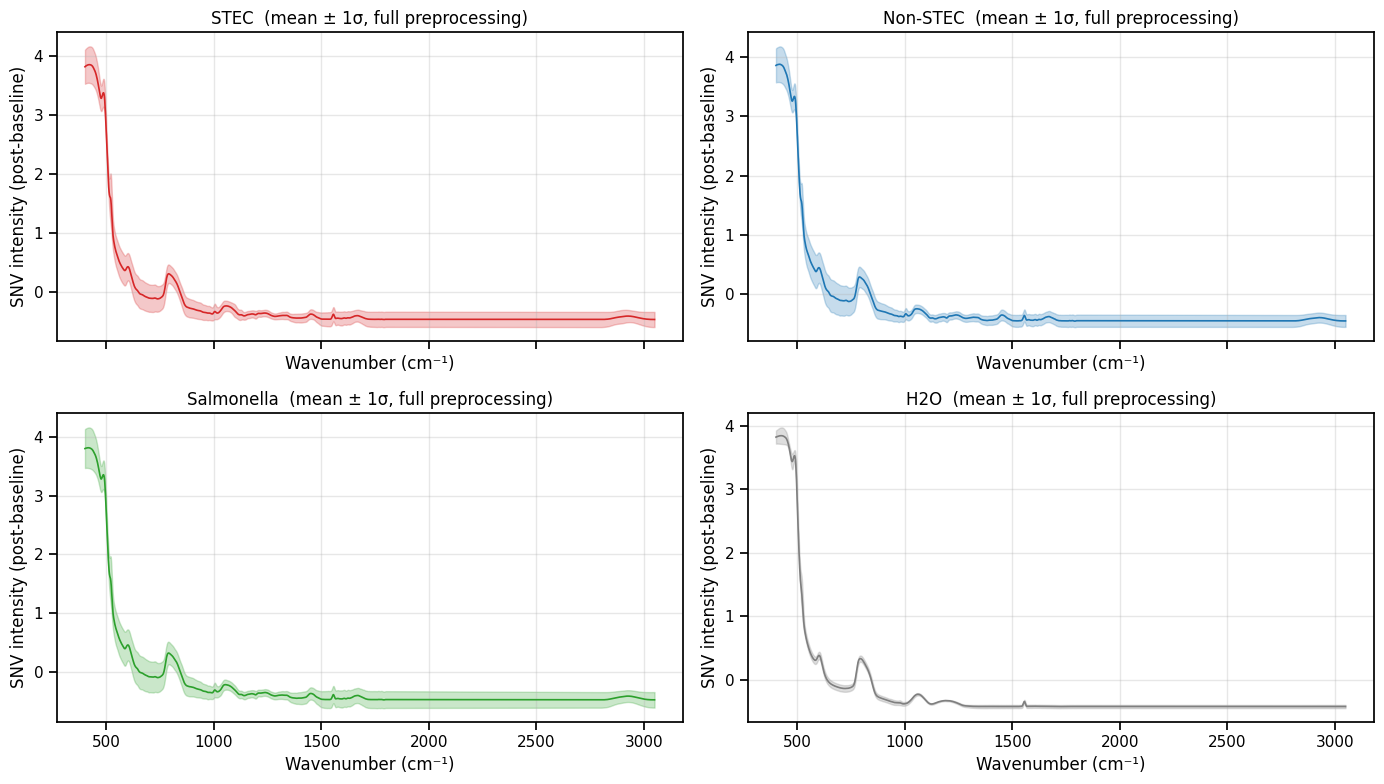

In [18]:
stats_p = mean_std_per_class(Xq, labels_class_q)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, c in zip(axes.flat, CLASS_ORDER):
    mu, sd = stats_p[c]
    ax.fill_between(wnp, mu - sd, mu + sd, alpha=0.25, color=CLASS_COLORS[c])
    ax.plot(wnp, mu, color=CLASS_COLORS[c], lw=1.2)
    ax.set_title(f"{c}  (mean ± 1σ, full preprocessing)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("SNV intensity (post-baseline)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT2 / "09a_class_means_processed.png", bbox_inches="tight")
plt.show()

### 9.2 — PCA scatter (preprocessed)

Compare against Block 3 — if baseline removal worked, PC1 should carry a
much smaller fraction of variance (chemistry is less monolithic than
fluorescence), and the scatter shouldn't be dominated by one outlier
direction.

top-10 var explained: [0.695 0.152 0.061 0.031 0.014 0.011 0.008 0.007 0.006 0.003]
cumulative top-10  : [0.695 0.846 0.907 0.938 0.952 0.963 0.971 0.978 0.984 0.987]

Compare to raw+SNV (Block 3): PC1 was 0.801 (80%) of variance
After full preprocess       : PC1 = 0.695


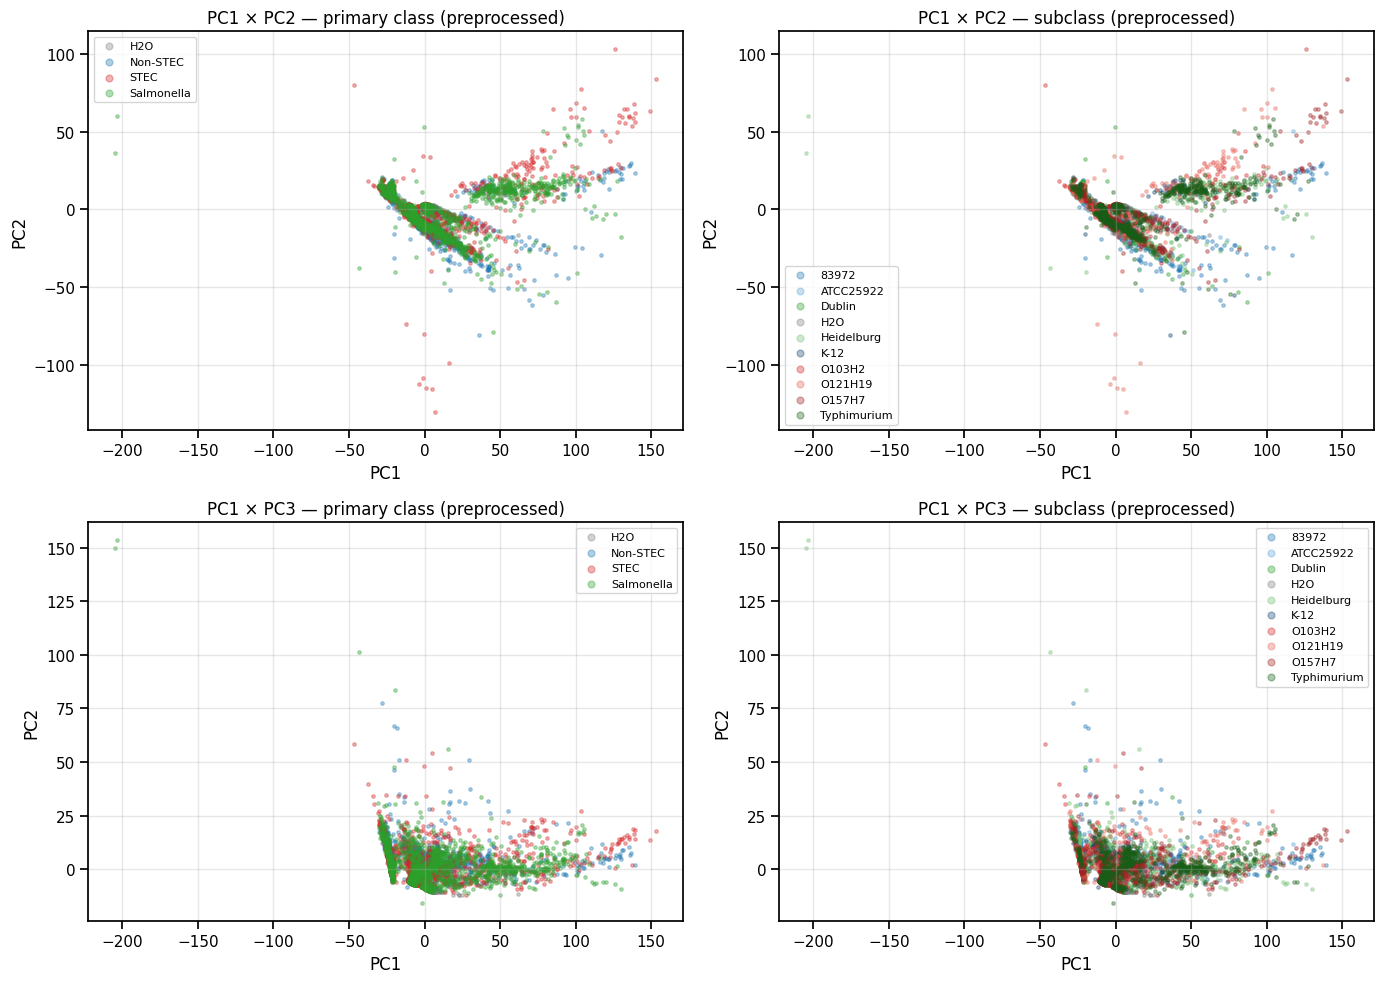

In [19]:
scaler_p = StandardScaler()
Xs_p = scaler_p.fit_transform(Xq)
pca_p = PCA(n_components=20, random_state=0).fit(Xs_p)
Zp = pca_p.transform(Xs_p)
print(f"top-10 var explained: {np.round(pca_p.explained_variance_ratio_[:10], 3)}")
print(f"cumulative top-10  : {np.round(pca_p.explained_variance_ratio_[:10].cumsum(), 3)}")
print()
print(f"Compare to raw+SNV (Block 3): PC1 was 0.801 (80%) of variance")
print(f"After full preprocess       : PC1 = {pca_p.explained_variance_ratio_[0]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scatter(axes[0, 0], Zp[:, 0], Zp[:, 1], labels_class_q, CLASS_COLORS,
        "PC1 × PC2 — primary class (preprocessed)")
scatter(axes[0, 1], Zp[:, 0], Zp[:, 1], labels_sub_q,
        {**SUBCLASS_COLORS, "H2O": "#7f7f7f"},
        "PC1 × PC2 — subclass (preprocessed)")
for ax in axes[1]:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC3")
scatter(axes[1, 0], Zp[:, 0], Zp[:, 2], labels_class_q, CLASS_COLORS,
        "PC1 × PC3 — primary class (preprocessed)")
scatter(axes[1, 1], Zp[:, 0], Zp[:, 2], labels_sub_q,
        {**SUBCLASS_COLORS, "H2O": "#7f7f7f"},
        "PC1 × PC3 — subclass (preprocessed)")
plt.tight_layout()
plt.savefig(OUT2 / "09b_pca_processed.png", bbox_inches="tight")
plt.show()

### 9.3 — UMAP (preprocessed)

Local-neighbor projection on the first 50 preprocessed PCs.

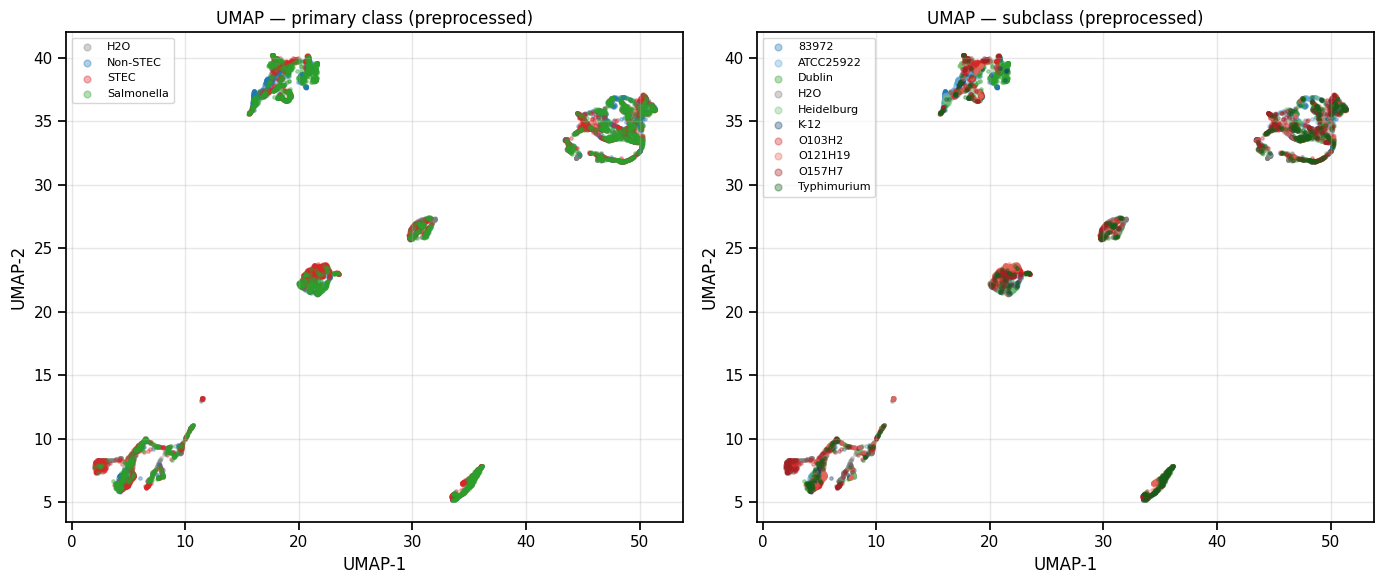

In [20]:
reducer_p = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=0)
Up = reducer_p.fit_transform(Zp[:, :50])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter(axes[0], Up[:, 0], Up[:, 1], labels_class_q, CLASS_COLORS,
        "UMAP — primary class (preprocessed)")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
scatter(axes[1], Up[:, 0], Up[:, 1], labels_sub_q,
        {**SUBCLASS_COLORS, "H2O": "#7f7f7f"},
        "UMAP — subclass (preprocessed)")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
plt.tight_layout()
plt.savefig(OUT2 / "09c_umap_processed.png", bbox_inches="tight")
plt.show()

### 9.4 — Inter-file similarity (preprocessed)

If the all-yellow heatmap in Block 7 was caused by baselines drowning out
chemistry, this version should show much more block-diagonal structure.

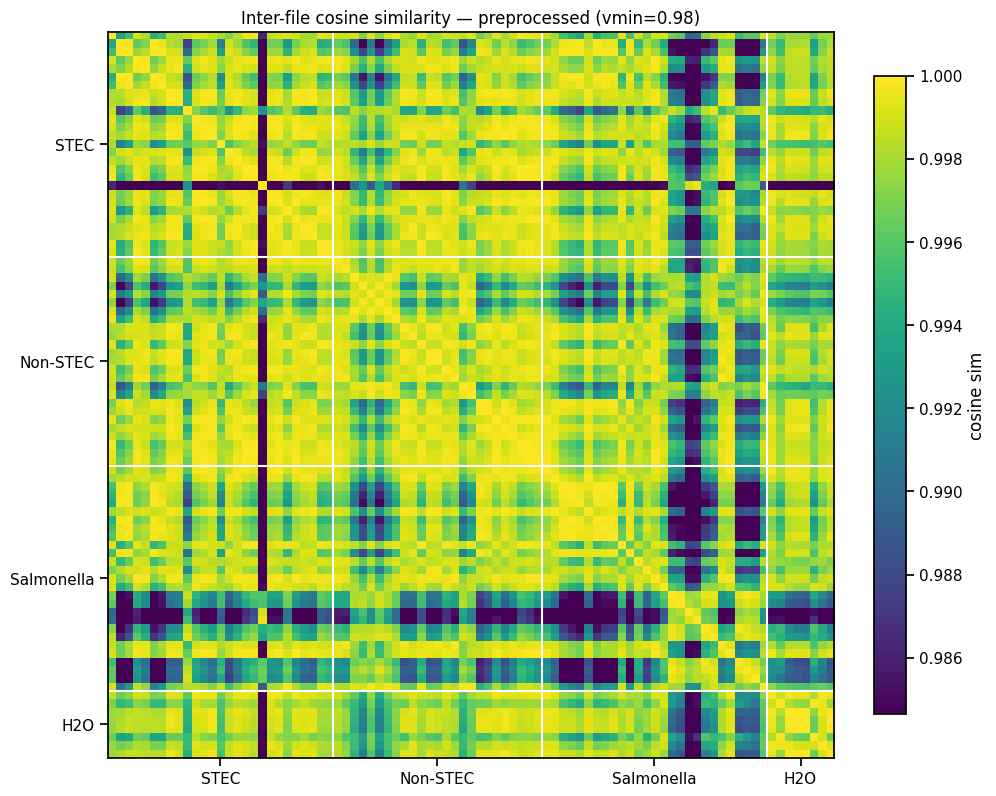

Per-class intra-class mean cosine similarity (preprocessed):
  STEC          n_pairs=351  mean=0.997  min=0.963
  Non-STEC      n_pairs=300  mean=0.998  min=0.990
  Salmonella    n_pairs=351  mean=0.993  min=0.970
  H2O           n_pairs=28  mean=0.999  min=0.996

(In Block 7 these were all ≥ 0.99 — looking for lower / more spread numbers now)


In [21]:
# Per-file mean of preprocessed data
file_means_p = []
file_ids_p = []
file_labels_p = []
spec_q_idx = spec_q.reset_index(drop=True)
for fid, g in spec_q_idx.groupby("file_id", sort=False):
    file_ids_p.append(fid)
    idx = g.index.to_numpy()
    file_means_p.append(Xq[idx].mean(0))
    pc = g["primary_class"].iloc[0]
    sc = g["subclass"].iloc[0]
    file_labels_p.append((pc, sc if isinstance(sc, str) else "—"))
file_means_p = np.asarray(file_means_p)

order_p = sorted(range(len(file_ids_p)),
                 key=lambda i: (CLASS_ORDER.index(file_labels_p[i][0]),
                                file_labels_p[i][1], file_ids_p[i]))
file_means_ps = file_means_p[order_p]
labels_ps = [file_labels_p[i] for i in order_p]

Sp = cosine_similarity(file_means_ps)
fig, ax = plt.subplots(figsize=(10, 9))
# Use a contrast-stretched colormap focused on the relevant range
vmin = float(np.percentile(Sp, 5))
im = ax.imshow(Sp, cmap="viridis", vmin=vmin, vmax=1)
ax.set_title(f"Inter-file cosine similarity — preprocessed (vmin={vmin:.2f})")

# Class boundaries
class_boundaries_p = []
prev = None
for i, (pc, _) in enumerate(labels_ps):
    if pc != prev:
        class_boundaries_p.append((i, pc))
        prev = pc
for b, pc in class_boundaries_p[1:]:
    ax.axhline(b - 0.5, color="white", lw=1.5)
    ax.axvline(b - 0.5, color="white", lw=1.5)

tick_pos = []
tick_lbl = []
for b, pc in class_boundaries_p:
    end = next((bb for bb, _ in class_boundaries_p[class_boundaries_p.index((b, pc)) + 1:]),
               len(labels_ps))
    tick_pos.append((b + end) / 2 - 0.5)
    tick_lbl.append(pc)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbl)
plt.colorbar(im, ax=ax, fraction=0.04, label="cosine sim")
plt.tight_layout()
plt.savefig(OUT2 / "09d_interfile_heatmap_processed.png", bbox_inches="tight")
plt.show()

print("Per-class intra-class mean cosine similarity (preprocessed):")
for c in CLASS_ORDER:
    idxs = [i for i, (pc, _) in enumerate(labels_ps) if pc == c]
    if len(idxs) < 2:
        continue
    block = Sp[np.ix_(idxs, idxs)]
    iu = np.triu_indices_from(block, k=1)
    print(f"  {c:12s}  n_pairs={len(iu[0])}  mean={block[iu].mean():.3f}  min={block[iu].min():.3f}")
print()
print("(In Block 7 these were all ≥ 0.99 — looking for lower / more spread numbers now)")

### 9.5 — Silhouette by subclass (preprocessed)

Block 8 showed overall silhouette of −0.25 (only H₂O was positive at +0.71).
Hoping for less-negative numbers across the bacterial subclasses now.

Overall subclass silhouette (preprocessed, PCA-50): -0.229
Before (raw+SNV)                                  : -0.254



Per-subclass mean silhouette (preprocessed):
             mean_sil    n
sub                       
H2O          0.479179  379
Dublin      -0.127114  428
ATCC25922   -0.200901  422
K-12        -0.245931  328
O103H2      -0.263436  437
Typhimurium -0.294724  435
83972       -0.394495  315
O121H19     -0.396517  434
Heidelburg  -0.402772  417
O157H7      -0.421404  405


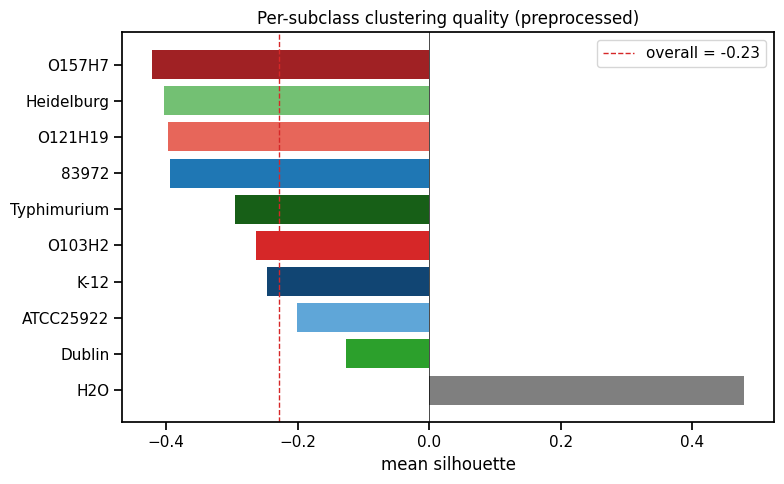

In [22]:
n_sample = min(4000, len(Xq))
idx_s = np.random.default_rng(0).choice(len(Xq), size=n_sample, replace=False)
score_p = silhouette_score(Zp[:, :50][idx_s], labels_sub_q[idx_s], metric="euclidean")
print(f"Overall subclass silhouette (preprocessed, PCA-50): {score_p:.3f}")
print(f"Before (raw+SNV)                                  : -0.254")

sample_vals_p = silhouette_samples(Zp[:, :50][idx_s], labels_sub_q[idx_s])
per_sub_p = pd.DataFrame({"sub": labels_sub_q[idx_s], "sil": sample_vals_p}).groupby("sub").agg(
    mean_sil=("sil", "mean"), n=("sil", "size")
).sort_values("mean_sil", ascending=False)
print()
print("Per-subclass mean silhouette (preprocessed):")
print(per_sub_p.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = [SUBCLASS_COLORS.get(s if s != "H2O" else None, "#7f7f7f") for s in per_sub_p.index]
ax.barh(per_sub_p.index, per_sub_p["mean_sil"], color=colors)
ax.axvline(0, color="k", lw=0.5)
ax.axvline(score_p, color="#d62728", ls="--", lw=1, label=f"overall = {score_p:.2f}")
ax.set_xlabel("mean silhouette")
ax.set_title("Per-subclass clustering quality (preprocessed)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT2 / "09e_silhouette_processed.png", bbox_inches="tight")
plt.show()

### 9.6 — Per-peak boxplots at known biological Raman bands

Instead of trying to summarize 987 bins with PCA, look directly at 4
biologically-known peaks and box-plot the intensity per class. This is the
most concrete chemistry view we can give:

| Peak | Vibration | Biology |
|---|---|---|
| 1004 cm⁻¹ | phenylalanine ring | protein content |
| 1450 cm⁻¹ | CH₂ deformation | total lipid/protein |
| 1660 cm⁻¹ | amide-I | protein secondary structure |
| 2900 cm⁻¹ | C-H stretch | lipid + protein mass |

For each peak, we sum a ±10 cm⁻¹ window around the band.

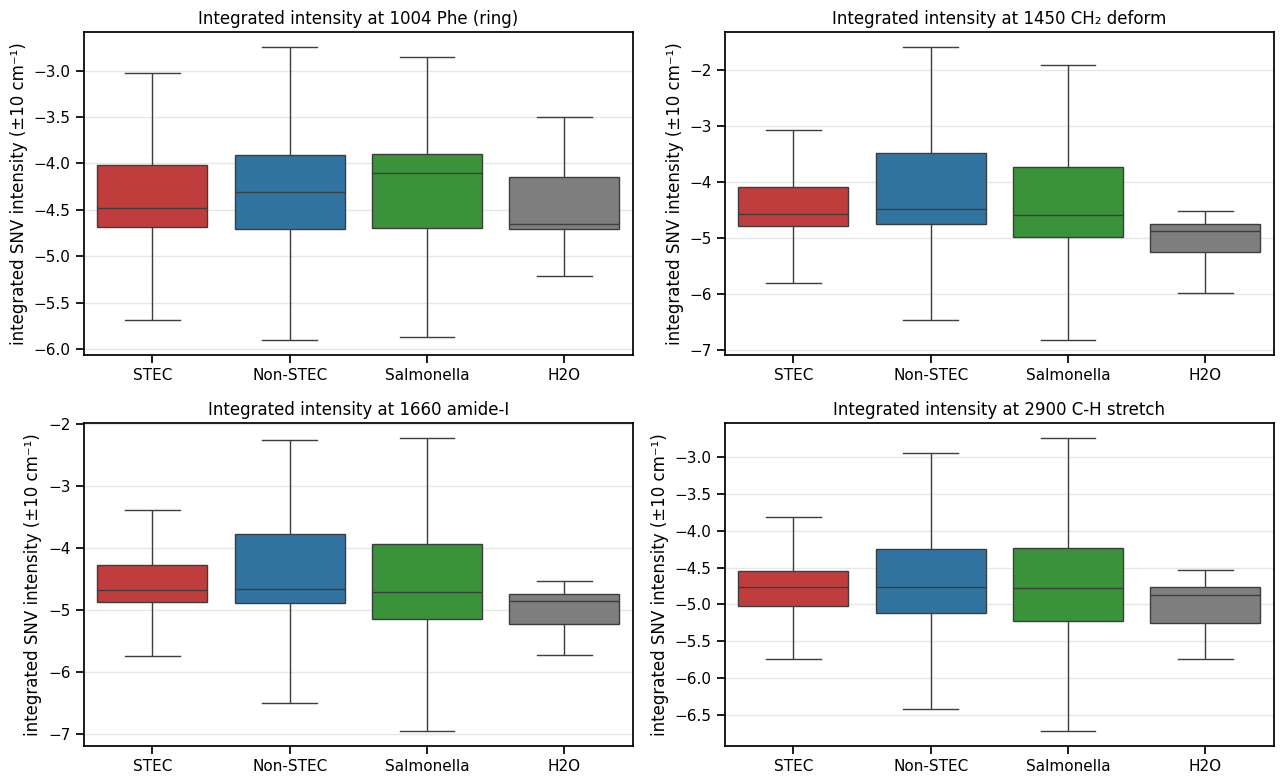

In [23]:
peaks_bio = [(1004, "1004 Phe (ring)"),
             (1450, "1450 CH₂ deform"),
             (1660, "1660 amide-I"),
             (2900, "2900 C-H stretch")]

def integrate_around(X, wn, center, half_width=10):
    m = (wn >= center - half_width) & (wn <= center + half_width)
    return X[:, m].sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (center, name) in zip(axes.flat, peaks_bio):
    vals = integrate_around(Xq, wnp, center)
    df_box = pd.DataFrame({"class": labels_class_q, "intensity": vals})
    df_box["class"] = pd.Categorical(df_box["class"], categories=CLASS_ORDER, ordered=True)
    sns.boxplot(data=df_box, x="class", y="intensity", ax=ax,
                palette=[CLASS_COLORS[c] for c in CLASS_ORDER],
                showfliers=False)
    ax.set_title(f"Integrated intensity at {name}")
    ax.set_ylabel("integrated SNV intensity (±10 cm⁻¹)")
    ax.set_xlabel("")
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUT2 / "09f_peak_boxplots.png", bbox_inches="tight")
plt.show()

### 9.7 — PCA colored by calibration date (batch-effect probe)

If files calibrated on the same day cluster together in PCA space *regardless
of what's under the laser*, that's instrument signature — bad news for
generalization. This is a quick read on whether we'll need a domain
adversary (DANN) later.

Pull `ac_calibration_date` from metadata and color the same PCA by it.

unique calibration dates: 12
['03.03.2026', '05.03.2026', '09.03.2026', '10.03.2026', '11.03.2026', '12.03.2026', '13.03.2026', '16.03.2026', '17.03.2026', '18.03.2026']


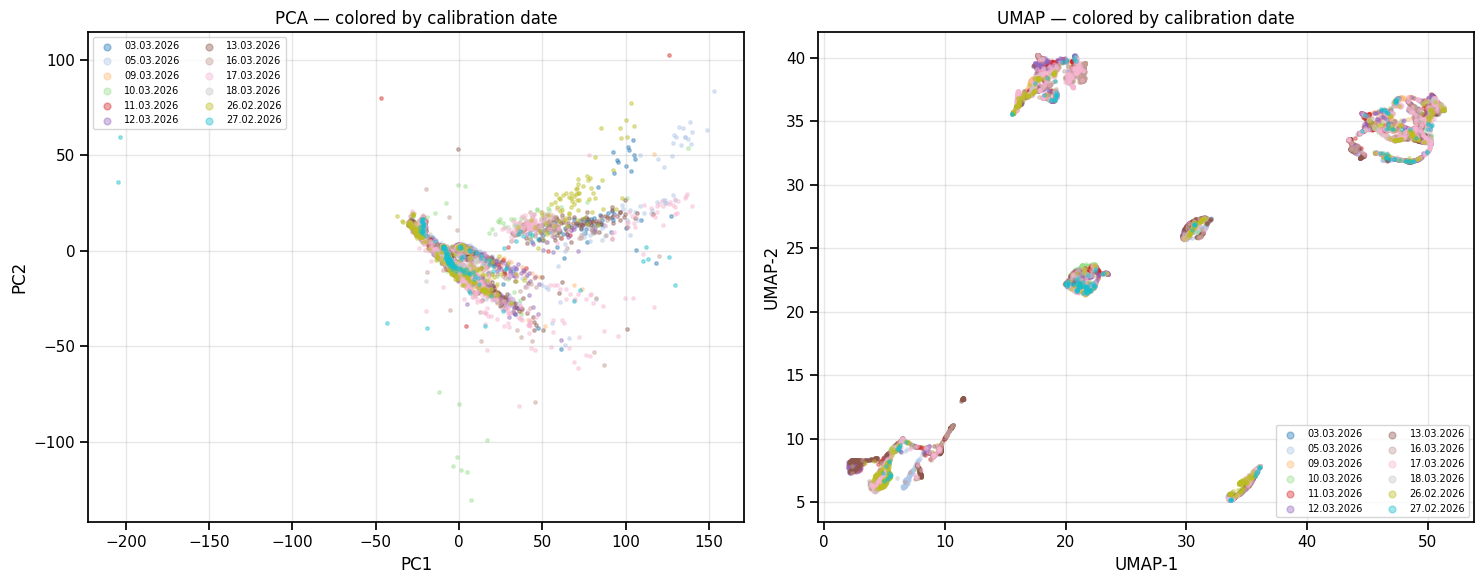


Mean file-to-file distance, same calibration date : 2.141
Mean file-to-file distance, different cal dates  : 2.398
Ratio (same/other): 0.893  (< 1.0 means same-date files DO cluster -> batch effect risk)


In [24]:
# Map each spectrum's file_id to its ac_calibration_date
date_map = dict(zip(meta["file_id"], meta["ac_calibration_date"]))
cal_dates = np.array([date_map.get(fid, "unknown")[:10] if date_map.get(fid) else "unknown"
                      for fid in spec_q["file_id"]])

unique_dates = sorted(set(cal_dates))
print(f"unique calibration dates: {len(unique_dates)}")
print(unique_dates[:10])

# Color palette
import matplotlib.cm as cm
date_palette = {d: cm.tab20(i / max(len(unique_dates), 1)) for i, d in enumerate(unique_dates)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (xs, ys, title) in zip(axes, [
    (Zp[:, 0], Zp[:, 1], "PCA — colored by calibration date"),
    (Up[:, 0], Up[:, 1], "UMAP — colored by calibration date"),
]):
    for d in unique_dates:
        m = cal_dates == d
        ax.scatter(xs[m], ys[m], s=6, alpha=0.4, color=date_palette[d], label=d)
    ax.set_title(title)
    ax.legend(fontsize=7, loc="best", markerscale=2, ncol=2)
    ax.grid(alpha=0.3)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
plt.tight_layout()
plt.savefig(OUT2 / "09g_batch_effect_pca.png", bbox_inches="tight")
plt.show()

# Quantify: do same-date files cluster more than chance?
# For each pair of files (i,j), are they "close" in PCA-50 space? Then ask
# whether the same-date pair rate is higher than the random pair rate.
from sklearn.metrics import pairwise_distances
file_centroids = file_means_ps  # already aligned with labels_ps order
# Match file order to calibration dates
file_cal = []
for fid, _ in zip([file_ids_p[i] for i in order_p], labels_ps):
    file_cal.append(date_map.get(fid, "unknown")[:10] if date_map.get(fid) else "unknown")

D = pairwise_distances(file_centroids)
np.fill_diagonal(D, np.nan)
nf = len(file_cal)
same_date = np.zeros((nf, nf), dtype=bool)
for i in range(nf):
    for j in range(nf):
        if i != j and file_cal[i] == file_cal[j]:
            same_date[i, j] = True

mean_same_date = np.nanmean(D[same_date])
mean_other = np.nanmean(D[~same_date])
print(f"\nMean file-to-file distance, same calibration date : {mean_same_date:.3f}")
print(f"Mean file-to-file distance, different cal dates  : {mean_other:.3f}")
print(f"Ratio (same/other): {mean_same_date / mean_other:.3f}  "
      f"(< 1.0 means same-date files DO cluster -> batch effect risk)")

## Summary

Artifacts:

**`outputs/eda/`** — Blocks 1–8 on **raw + SNV-only** data (preserved as
the "before preprocessing" baseline so we can see the journey).

**`outputs/eda_v2/`** — Block 9 on **full-preprocessing** data.

| File | What it shows |
|---|---|
| `09a_class_means_processed.png` | Class means after arPLS — distinct peaks visible |
| `09b_pca_processed.png` | PCA scatter after preprocessing |
| `09c_umap_processed.png` | UMAP after preprocessing |
| `09d_interfile_heatmap_processed.png` | Inter-file heatmap (block-diagonal hopefully visible) |
| `09e_silhouette_processed.png` | Silhouette by subclass — compare to Block 8 |
| `09f_peak_boxplots.png` | Per-peak boxplots at known biological bands |
| `09g_batch_effect_pca.png` | PCA colored by calibration date (batch-effect probe) |

Next steps (per PLAN.md §5):
1. ✅ `atlas/io.py` + `scripts/build_dataset.py`
2. ✅ EDA notebook blocks 1–8
3. ✅ `atlas/preprocess.py` + `atlas/qc.py`
4. **Next: `atlas/splits.py`** — StratifiedGroupKFold + LOSO.
5. Classical models, CNN, transformer.